# Scientific Programming and Algorithms in Bioinformatics  
### Electronic laboratory notebook (ELN)  

**Date**: 05-03-2025  

## Task 1. Needleman-Wunsch algorithm

------------------------------------------------------------------------

In this exercise you will align two short sequences by using the Needleman-Wunsch algorithm. The sequences (*$S$) are `HGSAQVKGHG` and `KTEAEMKASEDLKKHGT`, which are part of hemoglobin (PDB code 1AOW) and myoglobin 1 (PDB code 1AZI).

The similarity scores $S_{i,j}$ should be obtained from looking up the matches at the BLOSUM40 matrix:

<img src=./images/blosum40.png width="700">

*Figure 1. BLOSUM40: Blocks Substitution Matrix.*

------------------------------------------------------------------------

### Method

Given this task the following relashionship is used to compute the Needleman-Wunsch $F$ matrix, where the gap penalty is -8:

$F_{𝑖𝑗} = 𝑚𝑎𝑥(𝑚𝑎𝑡𝑐ℎ, S1\_Indel, S2\_Indel)$

Which in this case are:

$𝑚𝑎𝑡𝑐ℎ = F((𝑖−1),(𝑗−1)) + 𝑠𝑐𝑜𝑟𝑒 = F(𝑖−1)(𝑗−1) + 𝐵𝐿𝑂𝑆𝑈𝑀40(S1(𝑖−1)),(S2(𝑗−1))$\
$S1\_Indel = F((𝑖−1),𝑗) − 8$\
$S2\_Indel = F(𝑖,(𝑗−1)) − 8$

We move top to bottom calculating these results. Every time a maximum score is selected we draw an arrow from where it came. If two results yield the same score we draw arrows for both.

<img src=./images/F_mat.jpeg width="700">

*Figure 2. $F$ matrix resulting from applying BLOSUM40 and Needleman-Wunsch algorithm on the sequences `KTEAEMKASEDLKKHGT` and `HGSAQVKGHG`*





Once we have this matrix we can immediately observe that the **alignment score resulting is -21**.

In order to see how many alignments are possible from this result we need to trace back the matrix from the right lower corner and move from bottom to top following the arrows:

<img src=./images/F_matSolved.jpeg width="700">

*Figure 3. Obtain alignments from the $F$ matrix moving bottom to top.*


### Results

Alignment 1 between sequence 1 (S1) and sequence 2 (S2):

| S1 | K | T | E | A | E | M | K | A | S | E | D | L | K | K | H | G | T |
|----|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| S2 | - | - | H | G | S | - | - | A | - | Q | - | V | K | G | H | G | - |

Alignment 2 between sequence 1 (S1) and sequence 2 (S2):

| S1 | K | T | E | A | E | M | K | A | S | E | D | L | K | K | H | G | T |
|----|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| S2 | - | - | H | G | - | - | S | A | - | Q | - | V | K | G | H | G | - |

The same best score is obtained for these two alignment. As we can see in Figure 3 there are two alternative routes for aligning the 3rd residue of sequence 2 (S), which can align with sequence 1 at the 5th residue (E) or at the 7th residue (K).

---


## Task 2. Multiple sequence alignment

---

Given the multiple sequence set:

```py     
S1: PPGVKSDCAS
S2: PADGVKDCAS
S3: PPDGKSDS
S4: GADGKDCCS
S5: GADGKDCAS
```

Use the popular progressive alignment method to globally align the previous set of sequences. Generate the guide tree by neighbord-joining. Compare your outcome (alignment) with the one from Clustal-Omega.

With the final alignment represent the logo. For this purpose null or gap characters are ignored, and not counted toward the number of observations in a column.

------------------------------------------------------------------------

### Progressive Alignment Procedure:

The following block of code does two things:

1.  Performs a **pairwise alignment** between all the sequences
2.  Computes the **distance matrix**, which refers to the genetic distance determined by number of mismatches divided by number of matches. Lower distance means more similarity between them.


In [ ]:
from Bio import Align

aligner = Align.PairwiseAligner(match_score=1.0)

sequences = ["PPGVKSDCAS", "PADGVKDCAS", 
             "PPDGKSDS", "GADGKDCCS", "GADGKDCAS"]

n = len(sequences)

# Initialize distance matrix
distance_matrix = [[0.0 for _ in range(n)] for _ in range(n)]

# Compute alignments, fill in matrix and extract log
with open("log.txt", "w") as log_file:
    log_file.write("=== Pairwise Alignment Log ===\n\n")

    for i in range(n):
        for j in range(i, n):  
            seq1 = sequences[i]
            seq2 = sequences[j]
            score = aligner.score(seq1, seq2)

            identity = score / len(seq1)
            distance = 1 - identity
            rounded_distance = round(distance, 2)
            
            distance_matrix[i][j] = rounded_distance
            distance_matrix[j][i] = rounded_distance
            
            alignments = aligner.align(seq1, seq2)
            for alignment in alignments:
                log_file.write(f"""
Alignment s{i+1} vs s{j+1}:
{alignment}
    ** Identity = {round(identity, 2)}
    ** Distance = {rounded_distance}\n\n""")

print("*** Alignment process completed. Log saved to log.txt ***")


Alignment process completed. Log saved to log.txt



The distance matrix created is symmetric, the lower triangle mirrors the upper triangle:

In [4]:
print("=== Distance Matrix ===")
df = pd.DataFrame(
    distance_matrix,
    columns=[f"s{i+1}" for i in range(n)],
    index=[f"s{i+1}" for i in range(n)]
)
print(df)

=== Distance Matrix ===
     s1   s2    s3    s4    s5
s1  0.0  0.2  0.30  0.50  0.40
s2  0.2  0.0  0.40  0.30  0.20
s3  0.3  0.4  0.00  0.38  0.38
s4  0.5  0.3  0.38  0.00  0.11
s5  0.4  0.2  0.38  0.11  0.00


3.  Now we will build the **guide tree**. To do this we will cluster sequence according to distance (similarity) using the Unweighted Pair Group Method with Arithmetic Mean (UPGMA), which is a greedy hierarchical clustering algorithm. We will apply it through [linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html), a clustering package included in `scipy.cluster` specifically used to perform hierarchical clustering.

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert full matrix to condensed form
condensed_dist_matrix = squareform(distance_matrix)

# Perform hierarchical clustering using UPGMA
linkage_matrix = linkage(condensed_dist_matrix, method="average")

These are the steps that the algorithm followed to produce the tree:

In [6]:
print("=== UPGMA Clustering Steps ===")
print("Cluster 1 | Cluster 2 | Distance | Cluster Size")
for i, row in enumerate(linkage_matrix):
    c1, c2, dist, size = row
    print(f"{int(c1)}         | {int(c2)}         | {dist:.2f}     | {int(size)}")

=== UPGMA Clustering Steps ===
Cluster 1 | Cluster 2 | Distance | Cluster Size
3         | 4         | 0.11     | 2
0         | 1         | 0.20     | 2
2         | 6         | 0.35     | 3
5         | 7         | 0.36     | 5


> \[*NOTE:*\] Sice we are using Python we should keep in mind that those results indexes start from 0, instead of 1. Therefore our sequence 1 is the 0, sequence 2 is the 1 and so on...

In the previous table we can see how the algorithm worked internally to create the tree. We can observe the following:

-   It started clustering the sequence 4 (index 3) and 5 (index 4), which had the shortest distance (0.11) and formed a cluster of these 2, named cluster 5.
-   It continued with sequences 1 and 2, that had a distance of 0.2 and were paired as cluster 6.
-   This was followed by joining the sequence 3 and cluster 6 (with sequences 1 and 2), that created a cluster of 3, named cluster 7.
-   Lastly, clusters 5 and 7 were joined to form the final cluster of 5 sequences.

This is the resulting tree:

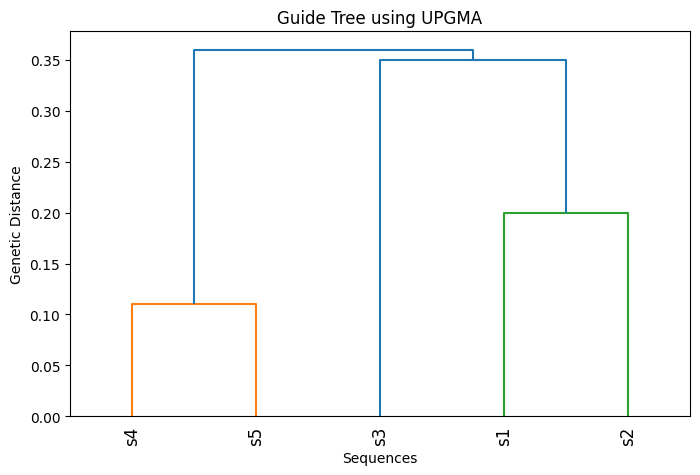

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=[f"s{i+1}" for i in range(n)], leaf_rotation=90)
plt.title("Guide Tree using UPGMA")
plt.xlabel("Sequences")
plt.ylabel("Genetic Distance")
plt.show()

4.  In this last step of the multiple sequence alignment we need to align sequences sequentially, guided by the tree, this is called a **progressive alignment**:
    - We did this by choosing the paired alignments performed on the first block of code. We just made sure to take the alignment with the least amount of gaps.
    - In this way we aligned s4 and s5, followed by s1 and s2, then s1-s2 to s3 and lastly all s1-s2-s3 to s4-s5:

```py    
Progressive Multiple Sequence Alignment (MSA)

Step 1: Alignment of sequence 4 and 5
target         GADGKDCCS 
               |||||||.| 
query          GADGKDCAS 

Step 2: Alignment of sequence 1 and 2
s1            PP-GVKSDCAS
              |.-|||-||||
s2            PADGVK-DCAS

Step 3: Alignment of sequence 3 to the 1 and 2
s3            PPDG-KSD--S
s1            PP-GVKSDCAS
              |.-|||-||||
s2            PADGVK-DCAS

Step 4: The last step consisted of the alignment of sequences 1,2,3 to sequences 4 and 5 which yielded the final MSA.
```

<br>

The **results** are therefore:

```py        
=== Multiple Sequence Alignment (MSA) ===
s3             PPDG-KSD--S  
s1             PP-GVKSDCAS  
s2             PADGVK-DCAS  
s4             GADG-K-DCCS  
s5             GADG-K-DCAS
```

### Results comparison with Clustal W and Clustal Omega online tools:

If we compare our results with those of [ClustalW online](https://www.genome.jp/tools-bin/clustalw) tool:

```ruby      
CLUSTAL_W 2.1 Multiple Sequence Alignments

Sequence 1: s1             10 aa
Sequence 2: s2             10 aa
Sequence 3: s3              8 aa
Sequence 4: s4              9 aa
Sequence 5: s5              9 aa
Start of Pairwise alignments
Aligning...

Group 1: Sequences:   2      Score:124
Group 2: Sequences:   3      Score:70
Group 3: Sequences:   2      Score:144
Group 4: Sequences:   5      Score:63

CLUSTAL_W Multiple Sequence Alignments Results
s1               PP-GVKSDCAS
s3               PPDG-KSD--S
s2               PADGVK-DCAS
s4               GADG-K-DCCS
s5               GADG-K-DCAS
```

We can see that results are the same as ours.

However when compared to [**Clustal Omega**](https://www.ebi.ac.uk/jdispatcher/msa/clustalo), we can see that there is already difference when it comes to the guide tree that Clustal Omega used:

<img src=./images/treeClustalO.svg width="400">

*Figure 4. Clustal Omega Guide tree.*

Here the closest sequences are the number 4 and 5, like in our results, however, Clustal Omega relates s4-5 to s2 and the sister taxa is s1-s3. Furthermore, the alignment results are the following:

```ruby
EMBOSS_001      PPGVKSDCAS  10
EMBOSS_003      PPDGKSDS--  8
EMBOSS_002      PADGVKDCAS  10
EMBOSS_004      -GADGKDCCS  9
EMBOSS_005      -GADGKDCAS  9
```

Probably, the diference in results obtained is due to the fact that we used UPGAMA to create the guide tree, whilst Clustal Omega uses neighbour-joining. The Clustal Omega results show a lesser use of gaps, which makes this alignment more likely to be biologically accurate, since it is questionable that all those gaps and changes present in our alignment will actually occur in reality.


### Logo representation
Motif logos illustrate the conserved and variable regions of a multiple sequence alignment.

From this excercise we produced the following alignment:

PP-GVKSDCAS\
PPDG-KSD--S\
PADGVK-DCAS\
GADG-K-DCCS\
GADG-K-DCAS

In order to create a motif logo representation we need to calculate the entropy of each letter, which is a measure of uncertainty for the probability of that residue.

The entropy $( H )$ of a discrete probability distribution $( P )$ with possible outcomes $ x_1, x_2, \dots, x_n $ is given by:

$
H(P) = -\sum_{i=1}^{n} P(x_i) * \log_2 P(x_i)
$

where:
- $ P(x_i) $ is the probability of outcome $ x_i $,
- $ \log_2 $ is the logarithm base 2 (resulting in entropy measured in *bits*),
- The sum is taken over all possible outcomes.

First we extract the profile matrix with the probability distribution:

```ruby
PP-GVKSDCAS
PPDG-KSD--S
PADGVK-DCAS
GADG-K-DCCS
GADG-K-DCAS

There are 8 possible letters in our motif: P, G, V, K, S, D, C and A

First column:
Probability of P = 3/5 = 0.6
Porbability of G = 2/5 = 0.4
Probability of any other letter = 0

Second column:
Probability of P = 2/5 = 0.4
Porbability of A = 3/5 = 0.6
Probability of any other letter = 0

Third column:
Probability of D = 4/5 = 0.8
Probability of any other letter = 0
...
```

... and repeating this on every column we obtain the following table:

```ruby
|   | 1   | 2   | 3   | 4 | 5   | 6 | 7   | 8 | 9   | 10  | 11 |
|---|-----|-----|-----|---|-----|---|-----|---|-----|-----|----|
| P | 0.6 | 0.4 | 0   | 0 | 0   | 0 | 0   | 0 | 0   | 0   | 0  |
| G | 0.4 | 0   | 0   | 1 | 0   | 0 | 0   | 0 | 0   | 0   | 0  |
| V | 0   | 0   | 0   | 0 | 0.4 | 0 | 0   | 0 | 0   | 0   | 0  |
| K | 0   | 0   | 0   | 0 | 0   | 1 | 0   | 0 | 0   | 0   | 0  |
| S | 0   | 0   | 0   | 0 | 0   | 0 | 0.4 | 0 | 0   | 0   | 1  |
| D | 0   | 0   | 0.8 | 0 | 0   | 0 | 0   | 1 | 0   | 0   | 0  |
| C | 0   | 0   | 0   | 0 | 0   | 0 | 0   | 0 | 0.8 | 0.2 | 0  |
| A | 0   | 0.6 | 0   | 0 | 0   | 0 | 0   | 0 | 0   | 0.6 | 0  |
```





We entered our multiple alignment in the Logo creation [website](https://weblogo.threeplusone.com/create.cgi) and obtained the following logo that we could compare with the probability table to have an idea of the distribution and confirmed that is correct.

<!-- ![*Figure 4. Clustal Omega Guide tree.*](/images/treeClustalO.svg){fig-align="center"} -->

<img src=./images/logoMSA.png width="700">

*Figure 5. Our MSA Logo.*